In [ ]:
%autosave 60

Autosaving every 60 seconds


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Path to your zip file in Drive
zip_path = "/content/drive/MyDrive/Agu_80-20_Split_SakSak_NewNew.zip"

# Destination directory to extract files
extract_to = "/content/drive/MyDrive/80-20_Hosa_New"

# Logging start
print("📁 Zip Path:", zip_path)
print("📂 Destination Directory:", extract_to)

# Make sure destination exists
if not os.path.exists(extract_to):
    print("📦 Creating destination directory...")
    os.makedirs(extract_to)
else:
    print("✅ Destination directory already exists.")

# Unzip the file
print("🔓 Starting to unzip the dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Unzipping complete.")
print("📄 Files extracted to:", extract_to)
print("📊 Total files extracted:", len(os.listdir(extract_to)))


📁 Zip Path: /content/drive/MyDrive/Agu_80-20_Split_SakSak_NewNew.zip
📂 Destination Directory: /content/drive/MyDrive/80-20_Hosa_New
✅ Destination directory already exists.
🔓 Starting to unzip the dataset...
✅ Unzipping complete.
📄 Files extracted to: /content/drive/MyDrive/80-20_Hosa_New
📊 Total files extracted: 1


In [ ]:
# Cell 2: Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile, EfficientNetB3
from tensorflow.keras.applications.nasnet import preprocess_input as nas_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Concatenate, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os

In [ ]:
# Set paths
save_dir = '/content/drive/MyDrive/NAS_EFF_80'
val_dir = '/content/drive/MyDrive/80-20_Hosa_New/Agu_80-20_Split_SakSak_NewNew/test'
img_size = 224
batch_size = 32


In [ ]:
# Load model
model = load_model(os.path.join(save_dir, 'trained_model.keras'))

# Reload validation generator
val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.nasnet.preprocess_input)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 1044 images belonging to 29 classes.


In [ ]:
# Cell 3: Configs
img_size = 224
batch_size = 32
num_classes = 29
epochs = 15

In [ ]:

# Imports
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import os


In [ ]:
# Load model
model = load_model(os.path.join(save_dir, 'trained_model.keras'))

# Reload validation generator
val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.nasnet.preprocess_input)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Found 1044 images belonging to 29 classes.


In [ ]:
# Evaluate
loss, acc = model.evaluate(val_generator)
print(f"\n✅ Final Test Accuracy: {acc*100:.2f}%")
print(f"✅ Final Test Loss: {loss:.4f}")

# Predictions
val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Save predictions
np.save(os.path.join(save_dir, 'predictions.npy'), y_pred_probs)
np.save(os.path.join(save_dir, 'true_labels.npy'), y_true)
np.save(os.path.join(save_dir, 'class_names.npy'), np.array(class_names))

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Classification Report:\n", report)
with open(os.path.join(save_dir, 'classification_report.txt'), 'w') as f:
    f.write(report)

# Misclassified
filenames = val_generator.filenames
misclassified = [
    f"{filenames[i]} - Predicted: {class_names[y_pred[i]]}, Actual: {class_names[y_true[i]]}"
    for i in range(len(y_pred)) if y_pred[i] != y_true[i]
]
with open(os.path.join(save_dir, 'misclassified.txt'), 'w') as f:
    f.write("\n".join(misclassified))


33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.9561 - loss: 0.8600

✅ Final Test Accuracy: 96.26%
✅ Final Test Loss: 0.8471
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step

📊 Classification Report:
                  precision    recall  f1-score   support

    Alexandrite       0.80      1.00      0.89        36
       Amethyst       0.86      0.89      0.88        36
     Aquamarine       0.94      0.83      0.88        36
     Bloodstone       1.00      1.00      1.00        36
Blue Lace Agate       1.00      1.00      1.00        36
      Carnelian       1.00      0.97      0.99        36
    Chrysoberyl       0.97      0.94      0.96        36
    Chrysoprase       1.00      1.00      1.00        36
        Citrine       1.00      0.97      0.99        36
        Diamond       0.97      1.00      0.99        36
        Emerald       1.00      0.83      0.91        36
       Fluorite       1.00      1.00      1.00        36
     Garnet Red       0.97      0.78      0.86        36
 

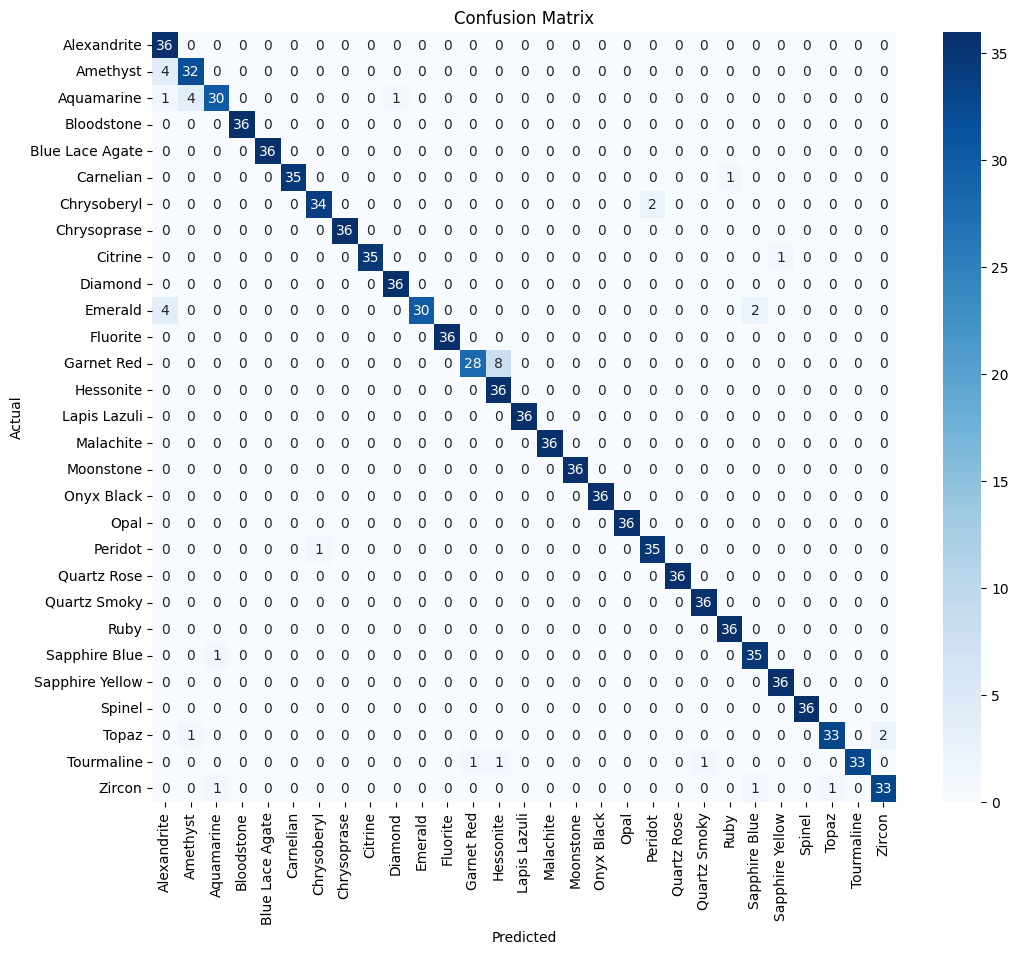

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Cell 4: Paths
save_dir = '/content/drive/MyDrive/NAS_EFF_80'
os.makedirs(save_dir, exist_ok=True)
train_dir = '/content/drive/MyDrive/80-20_Hosa_New/Agu_80-20_Split_SakSak_NewNew/train'
val_dir = '/content/drive/MyDrive/80-20_Hosa_New/Agu_80-20_Split_SakSak_NewNew/test'


In [ ]:
# Cell 5: Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=nas_preprocess,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(preprocessing_function=nas_preprocess)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4176 images belonging to 29 classes.
Found 1044 images belonging to 29 classes.


In [ ]:
# Cell 6: Hybrid Model
input_tensor = Input(shape=(img_size, img_size, 3))

nas = NASNetMobile(weights='imagenet', include_top=False, input_tensor=input_tensor)
eff = EfficientNetB3(weights='imagenet', include_top=False, input_tensor=input_tensor)

nas.trainable = False
eff.trainable = False

nas_out = GlobalAveragePooling2D()(nas.output)
eff_out = GlobalAveragePooling2D()(eff.output)

combined = Concatenate()([nas_out, eff_out])
combined = BatchNormalization()(combined)
combined = Dense(1024, activation='relu')(combined)
combined = Dropout(0.4)(combined)
output = Dense(num_classes, activation='softmax')(combined)

model = Model(inputs=input_tensor, outputs=output)


In [ ]:
# Cell 7: Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1, monitor='val_accuracy'),
    ModelCheckpoint(filepath=os.path.join(save_dir, 'best_model.h5'), monitor='val_accuracy', save_best_only=True, verbose=1)
]


In [ ]:
# Cell 8: Train (Stage 1 Only)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=callbacks
)
model.save(os.path.join(save_dir, 'trained_model.keras'))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.2637 - loss: 3.0021
Epoch 1: val_accuracy improved from -inf to 0.65326, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.2650 - loss: 2.9976 - val_accuracy: 0.6533 - val_loss: 2.0349 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.6710 - loss: 1.6040
Epoch 2: val_accuracy improved from 0.65326 to 0.80364, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 660ms/step - accuracy: 0.6712 - loss: 1.6035 - val_accuracy: 0.8036 - val_loss: 1.4134 - learning_rate: 1.0000e-04
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.7527 - loss: 1.3907
Epoch 3: val_accuracy improved from 0.80364 to 0.84962, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 661ms/step - accuracy: 0.7529 - loss: 1.3903 - val_accuracy: 0.8496 - val_loss: 1.1623 - learning_rate: 1.0000e-04
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8188 - loss: 1.2399
Epoch 4: val_accuracy improved from 0.84962 to 0.87835, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


...

131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 680ms/step - accuracy: 0.8979 - loss: 1.0439 - val_accuracy: 0.9397 - val_loss: 0.9269 - learning_rate: 1.0000e-04
Epoch 9/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9060 - loss: 1.0237
Epoch 9: val_accuracy did not improve from 0.93966
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 616ms/step - accuracy: 0.9060 - loss: 1.0236 - val_accuracy: 0.9349 - val_loss: 0.9040 - learning_rate: 1.0000e-04
Epoch 10/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.9177 - loss: 1.0021
Epoch 10: val_accuracy improved from 0.93966 to 0.95115, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 652ms/step - accuracy: 0.9177 - loss: 1.0021 - val_accuracy: 0.9511 - val_loss: 0.8855 - learning_rate: 1.0000e-04
Epoch 11/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.9192 - loss: 0.9908
Epoch 11: val_accuracy did not improve from 0.95115
131/131 ━━━━━━━━━━━━━━━━━━━━ 136s 604ms/step - accuracy: 0.9192 - loss: 0.9908 - val_accuracy: 0.9492 - val_loss: 0.8948 - learning_rate: 1.0000e-04
Epoch 12/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.9287 - loss: 0.9600
Epoch 12: val_accuracy improved from 0.95115 to 0.95307, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 656ms/step - accuracy: 0.9287 - loss: 0.9600 - val_accuracy: 0.9531 - val_loss: 0.8685 - learning_rate: 1.0000e-04
Epoch 13/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9305 - loss: 0.9566
Epoch 13: val_accuracy improved from 0.95307 to 0.95402, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 721ms/step - accuracy: 0.9305 - loss: 0.9566 - val_accuracy: 0.9540 - val_loss: 0.8681 - learning_rate: 1.0000e-04
Epoch 14/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9421 - loss: 0.9394
Epoch 14: val_accuracy improved from 0.95402 to 0.96264, saving model to /content/drive/MyDrive/NAS_EFF_80/best_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 662ms/step - accuracy: 0.9421 - loss: 0.9394 - val_accuracy: 0.9626 - val_loss: 0.8471 - learning_rate: 1.0000e-04
Epoch 15/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9349 - loss: 0.9354
Epoch 15: val_accuracy did not improve from 0.96264
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 614ms/step - accuracy: 0.9349 - loss: 0.9354 - val_accuracy: 0.9598 - val_loss: 0.8579 - learning_rate: 1.0000e-04


In [ ]:
# Cell 9: Save and Evaluate
history_all = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}
with open(os.path.join(save_dir, 'history.json'), 'w') as f:
    json.dump(history_all, f)

loss, acc = model.evaluate(val_generator)
print(f"\n✅ Final Test Accuracy: {acc*100:.2f}%")
print(f"✅ Final Test Loss: {loss:.4f}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.9561 - loss: 0.8600

✅ Final Test Accuracy: 96.26%
✅ Final Test Loss: 0.8471
